In [1]:
# Q1. Import libraries and create dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten
from sklearn.decomposition import PCA


In [2]:
texts = [
    "The product quality is excellent",
    "I really love this product",
    "The quality of this item is amazing",
    "The product performance is poor",
    "I dislike this product completely"
]

print("Dataset:")
for i, text in enumerate(texts, 1):
    print(i, text)

Dataset:
1 The product quality is excellent
2 I really love this product
3 The quality of this item is amazing
4 The product performance is poor
5 I dislike this product completely


In [3]:
# Q2. Pre-processing and vocabulary creation

cleaned_texts = [text.lower() for text in texts]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(cleaned_texts)

word_index = tokenizer.word_index

print("Vocabulary with Token IDs:")
for word, token_id in word_index.items():
    print(word, ":", token_id)

Vocabulary with Token IDs:
product : 1
the : 2
is : 3
this : 4
quality : 5
i : 6
excellent : 7
really : 8
love : 9
of : 10
item : 11
amazing : 12
performance : 13
poor : 14
dislike : 15
completely : 16


In [4]:
# Q3. Convert text into token sequences

sequences = tokenizer.texts_to_sequences(cleaned_texts)

print("Token Sequences:")
for i, seq in enumerate(sequences, 1):
    print("Sentence", i, ":", seq)

Token Sequences:
Sentence 1 : [2, 1, 5, 3, 7]
Sentence 2 : [6, 8, 9, 4, 1]
Sentence 3 : [2, 5, 10, 4, 11, 3, 12]
Sentence 4 : [2, 1, 13, 3, 14]
Sentence 5 : [6, 15, 4, 1, 16]


In [5]:
# Q4. Padding the sequences

max_length = max(len(seq) for seq in sequences)

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

print("Padded Sequences:")
print(padded_sequences)

print("\nShape:", padded_sequences.shape)

Padded Sequences:
[[ 2  1  5  3  7  0  0]
 [ 6  8  9  4  1  0  0]
 [ 2  5 10  4 11  3 12]
 [ 2  1 13  3 14  0  0]
 [ 6 15  4  1 16  0  0]]

Shape: (5, 7)


In [6]:
# Q5. Generate word embeddings

vocab_size = len(word_index) + 1
embedding_dim = 8

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
])

embedding_matrix = model.predict(padded_sequences)

print("Embedding Matrix Shape:", embedding_matrix.shape)

c:\Users\Neethu\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Embedding Matrix Shape: (5, 7, 8)


In [7]:
# Q6. Display word embeddings

for i in range(len(texts)):
    print("\nSentence", i + 1, ":", texts[i])
    print("Embedding representation:")
    print(np.round(embedding_matrix[i], 3))


Sentence 1 : The product quality is excellent
Embedding representation:
[[ 0.023  0.044  0.012  0.038  0.029  0.014  0.027  0.005]
 [ 0.019 -0.044 -0.035 -0.032 -0.025  0.024 -0.03   0.008]
 [-0.015 -0.008  0.014 -0.036 -0.003  0.01   0.005  0.004]
 [-0.039 -0.012 -0.004  0.024  0.032 -0.026 -0.048 -0.035]
 [ 0.028  0.012  0.016 -0.046 -0.047 -0.036 -0.04   0.034]
 [-0.015  0.048  0.02  -0.022  0.04   0.031 -0.034 -0.041]
 [-0.015  0.048  0.02  -0.022  0.04   0.031 -0.034 -0.041]]

Sentence 2 : I really love this product
Embedding representation:
[[ 0.05  -0.023  0.032  0.048  0.027 -0.016 -0.022  0.022]
 [-0.023 -0.023  0.026  0.036  0.008 -0.01   0.002 -0.032]
 [-0.048 -0.05   0.025 -0.035  0.026  0.023 -0.042  0.012]
 [ 0.018 -0.02   0.013  0.006 -0.023  0.014  0.006  0.026]
 [ 0.019 -0.044 -0.035 -0.032 -0.025  0.024 -0.03   0.008]
 [-0.015  0.048  0.02  -0.022  0.04   0.031 -0.034 -0.041]
 [-0.015  0.048  0.02  -0.022  0.04   0.031 -0.034 -0.041]]

Sentence 3 : The quality of thi

In [8]:
# Q7. Flatten embedding representations

flattened_vectors = embedding_matrix.reshape(
    embedding_matrix.shape[0],
    -1
)

print("Flattened Vector Shape:", flattened_vectors.shape)

for i, vector in enumerate(flattened_vectors, 1):
    print("\nSentence", i)
    print(np.round(vector, 3))

Flattened Vector Shape: (5, 56)

Sentence 1
[ 0.023  0.044  0.012  0.038  0.029  0.014  0.027  0.005  0.019 -0.044
 -0.035 -0.032 -0.025  0.024 -0.03   0.008 -0.015 -0.008  0.014 -0.036
 -0.003  0.01   0.005  0.004 -0.039 -0.012 -0.004  0.024  0.032 -0.026
 -0.048 -0.035  0.028  0.012  0.016 -0.046 -0.047 -0.036 -0.04   0.034
 -0.015  0.048  0.02  -0.022  0.04   0.031 -0.034 -0.041 -0.015  0.048
  0.02  -0.022  0.04   0.031 -0.034 -0.041]

Sentence 2
[ 0.05  -0.023  0.032  0.048  0.027 -0.016 -0.022  0.022 -0.023 -0.023
  0.026  0.036  0.008 -0.01   0.002 -0.032 -0.048 -0.05   0.025 -0.035
  0.026  0.023 -0.042  0.012  0.018 -0.02   0.013  0.006 -0.023  0.014
  0.006  0.026  0.019 -0.044 -0.035 -0.032 -0.025  0.024 -0.03   0.008
 -0.015  0.048  0.02  -0.022  0.04   0.031 -0.034 -0.041 -0.015  0.048
  0.02  -0.022  0.04   0.031 -0.034 -0.041]

Sentence 3
[ 0.023  0.044  0.012  0.038  0.029  0.014  0.027  0.005 -0.015 -0.008
  0.014 -0.036 -0.003  0.01   0.005  0.004  0.036  0.036 -0.044

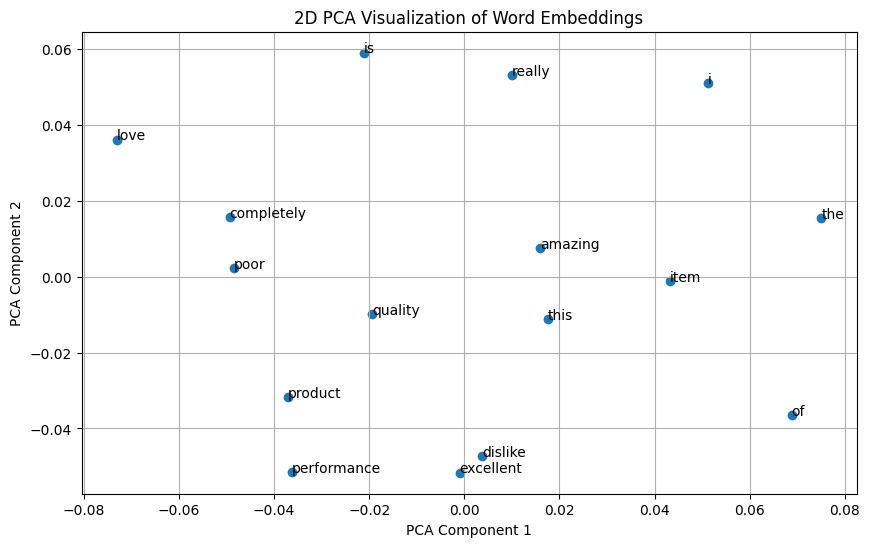

In [9]:
# Q8. PCA visualization of word embeddings

# Remove padding token (ID 0)
words = list(word_index.keys())
word_ids = list(word_index.values())

# Get embedding vectors for actual words
word_vectors = model.layers[0].get_weights()[0][word_ids]

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1]
)

for i, word in enumerate(words):
    plt.annotate(
        word,
        (pca_result[i, 0], pca_result[i, 1]),
        fontsize=10
    )

plt.title("2D PCA Visualization of Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

In [10]:
# Q9. Vocabulary table

vocabulary_df = pd.DataFrame(
    list(word_index.items()),
    columns=["Word", "Token ID"]
)

print(vocabulary_df)

           Word  Token ID
0       product         1
1           the         2
2            is         3
3          this         4
4       quality         5
5             i         6
6     excellent         7
7        really         8
8          love         9
9            of        10
10         item        11
11      amazing        12
12  performance        13
13         poor        14
14      dislike        15
15   completely        16


In [11]:
# Q10. Padded sequence table

padded_df = pd.DataFrame(
    padded_sequences,
    index=[f"Sentence {i}" for i in range(1, len(texts) + 1)]
)

print(padded_df)

            0   1   2  3   4  5   6
Sentence 1  2   1   5  3   7  0   0
Sentence 2  6   8   9  4   1  0   0
Sentence 3  2   5  10  4  11  3  12
Sentence 4  2   1  13  3  14  0   0
Sentence 5  6  15   4  1  16  0   0


In [13]:
# INTERPRETATION:
# 1. The text was converted into lowercase and a vocabulary of unique words was created.
#
# 2. Each word was assigned a unique token ID.
#
# 3. Each sentence was converted from text into numerical token sequences.
#
# 4. Padding made all sentences have the same length.
#
# 5. Word embeddings converted each token into an 8-dimensional numerical vector.
#
# 6. Similar words can have similar positions in the embedding space.
#
# 7. Flattening converted the complete embedding matrix of each sentence into one numerical vector.
#
# 8. PCA reduced the 8-dimensional word embeddings into 2 dimensions so they could be visualized.
#
# 9. The PCA graph helps us observe the relative positions of different words.
#
# 10. Overall, the process converts raw text into numerical feature vectors that can be used as input for machine learning or deep learning models.